# 06 - Experiment 4: Cross-Industry Portfolio Construction

Combine the 11 industry portfolio return series into master portfolios using
10 allocation methods.  Run on **two inputs**: Single-Factor (raw) and
IC-Composite (IC-weighted, rho<0.3) industry returns.

Methods: EqualWeight, InverseVol, MinVariance, MaxSharpe, RiskParity, HRP,
Momentum, BlackLitterman, MeanCVaR, TO_MVO.

In [1]:
import sys
sys.path.insert(0, '..')

import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf

from src.data_loader import INDUSTRIES, load_benchmark
from src.portfolio_construction import ALL_METHODS, CONSTRAINED_METHODS
from src.performance import (
    performance_table, is_vs_oos_table, plot_cumulative_returns,
    plot_correlation_heatmap, plot_drawdown, plot_weight_bars,
)

warnings.filterwarnings('ignore', category=RuntimeWarning)

DATA_DIR = '../data'
OUTPUT_DIR = '../output'
OOS_START = '2014-01-01'
COV_WINDOWS = [36, 60]

## 1. Load Data

Load Single-Factor and IC-Composite industry return series.

In [2]:
sf_returns = pd.read_csv(
    f'{OUTPUT_DIR}/csv/single_factor_raw_industry_returns.csv',
    index_col=0, parse_dates=True,
)
comp_returns = pd.read_csv(
    f'{OUTPUT_DIR}/csv/composite_all6_ew_industry_returns.csv',
    index_col=0, parse_dates=True,
)
benchmark = load_benchmark(DATA_DIR)

INPUT_SETS = {
    'SF': sf_returns,
    'All6EW': comp_returns,
}

for label, ret_df in INPUT_SETS.items():
    print(f'{label}: {ret_df.shape}, '
          f'{ret_df.index.min():%Y-%m} to {ret_df.index.max():%Y-%m}')
print(f'Industries: {list(sf_returns.columns)}')

Benchmark loaded: 289 months | 2001-05 to 2025-05
SF: (194, 11), 2009-02 to 2025-03
All6EW: (194, 11), 2009-02 to 2025-03
Industries: ['BMATR', 'CODIS', 'COSTP', 'ENEGY', 'FINAN', 'HLTHC', 'INDUS', 'RLEST', 'TECNO', 'TELCM', 'UTILS']


## 2. Covariance Estimation Utilities

- **Sample**: standard sample covariance
- **Ledoit-Wolf (LW)**: shrinkage estimator
- **EWMA**: exponentially-weighted moving average

In [3]:
def estimate_cov_sample(returns_df, **kwargs):
    return returns_df.cov().values


def estimate_cov_lw(returns_df, **kwargs):
    clean = returns_df.dropna()
    if len(clean) < returns_df.shape[1] + 1:
        return returns_df.cov().values
    return LedoitWolf().fit(clean).covariance_


def estimate_cov_ewma(returns_df, span=None, **kwargs):
    n = returns_df.shape[1]
    clean = returns_df.dropna()
    if span is None:
        span = len(clean)
    ewm_cov = clean.ewm(span=span).cov()
    return ewm_cov.iloc[-n:].values


COV_ESTIMATORS = {
    'Sample': estimate_cov_sample,
    'LW': estimate_cov_lw,
    'EWMA': estimate_cov_ewma,
}

## 3. Rolling Portfolio Construction

At each rebalance date, use the past `cov_window` months to estimate
covariance and expected returns, then compute optimal weights.  For
TO_MVO, the previous month's weights are passed to penalise turnover.

In [4]:
def rolling_backtest(industry_returns, methods, cov_window, cov_func,
                     cov_kwargs=None, verbose=True):
    if cov_kwargs is None:
        cov_kwargs = {}

    dates = industry_returns.index
    n_assets = industry_returns.shape[1]
    T = len(dates)
    fallback_w = np.ones(n_assets) / n_assets

    all_returns = {name: [] for name in methods}
    all_weights = {name: [] for name in methods}
    prev_weights = {name: fallback_w.copy() for name in methods}
    all_dates = []

    for i in range(cov_window, T):
        window_data = industry_returns.iloc[i - cov_window:i]
        window_clean = window_data.dropna()

        if len(window_clean) < max(n_assets + 1, cov_window // 2):
            for name in methods:
                all_returns[name].append(np.nan)
                all_weights[name].append(fallback_w.copy())
            all_dates.append(dates[i])
            continue

        cov_matrix = cov_func(window_clean, **cov_kwargs)
        mean_ret = window_clean.mean().values
        next_ret = np.nan_to_num(industry_returns.iloc[i].values, nan=0.0)

        for method_name, method_func in methods.items():
            bounds = (0.02, 0.20) if method_name in CONSTRAINED_METHODS else None
            extra_kw = {}
            if method_name == 'TO_MVO':
                extra_kw['prev_weights'] = prev_weights[method_name]
            try:
                w = method_func(
                    window_clean,
                    cov_matrix=cov_matrix,
                    mean_returns=mean_ret,
                    bounds=bounds,
                    **extra_kw,
                )
                w = np.asarray(w, dtype=float)
                if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                    w = fallback_w.copy()
                w = w / w.sum()
            except Exception:
                w = fallback_w.copy()

            all_returns[method_name].append(float(w @ next_ret))
            all_weights[method_name].append(w)
            prev_weights[method_name] = w.copy()

        all_dates.append(dates[i])

    returns_df = pd.DataFrame(all_returns, index=all_dates)
    returns_df.index.name = 'ym'
    weights_dict = {name: np.array(all_weights[name]) for name in methods}

    if verbose:
        print(f'    {len(returns_df)} months of portfolio returns'
              f' ({returns_df.index.min():%Y-%m} to {returns_df.index.max():%Y-%m})')

    return returns_df, weights_dict

## 4. Run All Methods on Both Inputs (LW Covariance)

Run all 10 methods with 36m and 60m windows on both Single-Factor
and IC-Composite industry returns.

In [5]:
results = {}
weights_store = {}

for input_label, industry_returns in INPUT_SETS.items():
    for window in COV_WINDOWS:
        tag = f'{input_label}_LW_{window}m'
        t0 = time.time()
        print(f'Running: {tag}')

        ret_df, w_dict = rolling_backtest(
            industry_returns, ALL_METHODS, window, estimate_cov_lw,
        )

        for method in ALL_METHODS:
            key = f'{method}_{tag}'
            results[key] = ret_df[method]
            weights_store[key] = w_dict[method]

        print(f'    Elapsed: {time.time() - t0:.1f}s')

print(f'\nTotal master portfolios: {len(results)}')

Running: SF_LW_36m


    158 months of portfolio returns (2012-02 to 2025-03)
    Elapsed: 13.8s
Running: SF_LW_60m


    134 months of portfolio returns (2014-02 to 2025-03)
    Elapsed: 12.0s
Running: All6EW_LW_36m


    158 months of portfolio returns (2012-02 to 2025-03)
    Elapsed: 15.5s
Running: All6EW_LW_60m


    134 months of portfolio returns (2014-02 to 2025-03)
    Elapsed: 14.1s

Total master portfolios: 40


### 4b. Covariance Sensitivity (SF, 60m window only)

Compare Sample and EWMA covariance alongside Ledoit-Wolf on the
Single-Factor input to check estimator sensitivity.

In [6]:
ALT_WINDOW = 60

for cov_name, cov_func in [('Sample', estimate_cov_sample),
                            ('EWMA', estimate_cov_ewma)]:
    tag = f'SF_{cov_name}_{ALT_WINDOW}m'
    t0 = time.time()
    print(f'Running: {tag}')

    cov_kw = {'span': ALT_WINDOW} if cov_name == 'EWMA' else {}
    ret_df, w_dict = rolling_backtest(
        sf_returns, ALL_METHODS, ALT_WINDOW, cov_func,
        cov_kwargs=cov_kw,
    )

    for method in ALL_METHODS:
        key = f'{method}_{tag}'
        results[key] = ret_df[method]
        weights_store[key] = w_dict[method]

    print(f'    Elapsed: {time.time() - t0:.1f}s')

print(f'\nTotal master portfolios: {len(results)}')

Running: SF_Sample_60m


    134 months of portfolio returns (2014-02 to 2025-03)
    Elapsed: 11.3s
Running: SF_EWMA_60m


    134 months of portfolio returns (2014-02 to 2025-03)
    Elapsed: 13.7s

Total master portfolios: 60


## 5. Combined Performance: SF vs Composite (LW 60m)

Side-by-side comparison of all 10 methods on both input types.

In [7]:
# Build LW 60m dicts for each input
sf_lw60 = {m: results[f'{m}_SF_LW_60m'] for m in ALL_METHODS}
a6_lw60 = {m: results[f'{m}_All6EW_LW_60m'] for m in ALL_METHODS}

# Full performance tables
common_sf = sf_lw60['EqualWeight'].dropna().index.intersection(benchmark.index)
common_a6 = a6_lw60['EqualWeight'].dropna().index.intersection(benchmark.index)
common = common_sf.intersection(common_a6)

sf_bench = {'MSCI EM': benchmark.loc[common]}
a6_bench = {}
for m in ALL_METHODS:
    sf_bench[m] = sf_lw60[m].loc[common]
    a6_bench[m] = a6_lw60[m].loc[common]

perf_sf = performance_table(sf_bench, benchmark=benchmark)
perf_a6 = performance_table(a6_bench, benchmark=benchmark)

# Combined display
print('=' * 95)
print('Combined Performance: LW 60m Covariance')
print('=' * 95)
header = f'{"Method":15s}  {"SF Sharpe":>10s}  {"SF Max DD":>10s}  {"All6EW Sharpe":>14s}  {"All6EW MaxDD":>13s}'
print(header)
print('-' * len(header))
for m in ALL_METHODS:
    ss = perf_sf.loc[m, 'Sharpe']
    sd = perf_sf.loc[m, 'Max DD']
    cs = perf_a6.loc[m, 'Sharpe']
    cd = perf_a6.loc[m, 'Max DD']
    print(f'{m:15s}  {ss:10.4f}  {sd:10.4f}  {cs:14.4f}  {cd:13.4f}')

bench_sharpe = perf_sf.loc['MSCI EM', 'Sharpe']
bench_dd = perf_sf.loc['MSCI EM', 'Max DD']
print(f'{"MSCI EM":15s}  {bench_sharpe:10.4f}  {bench_dd:10.4f}')
print()

Combined Performance: LW 60m Covariance
Method            SF Sharpe   SF Max DD   All6EW Sharpe   All6EW MaxDD
----------------------------------------------------------------------
EqualWeight          0.4501      0.3106          0.4771         0.2861
InverseVol           0.4300      0.3065          0.4545         0.2940
MinVariance          0.3933      0.3011          0.4105         0.3171
MaxSharpe            0.4315      0.3414          0.5054         0.3139
RiskParity           0.4494      0.3084          0.4652         0.2899
HRP                  0.4449      0.3190          0.4439         0.2950
Momentum             0.5181      0.2641          0.5943         0.2529
BlackLitterman       0.4381      0.3340          0.5068         0.2889
MeanCVaR             0.3433      0.3287          0.3925         0.3223
TO_MVO               0.4809      0.3153          0.5304         0.2836
MSCI EM              0.1796      0.3837



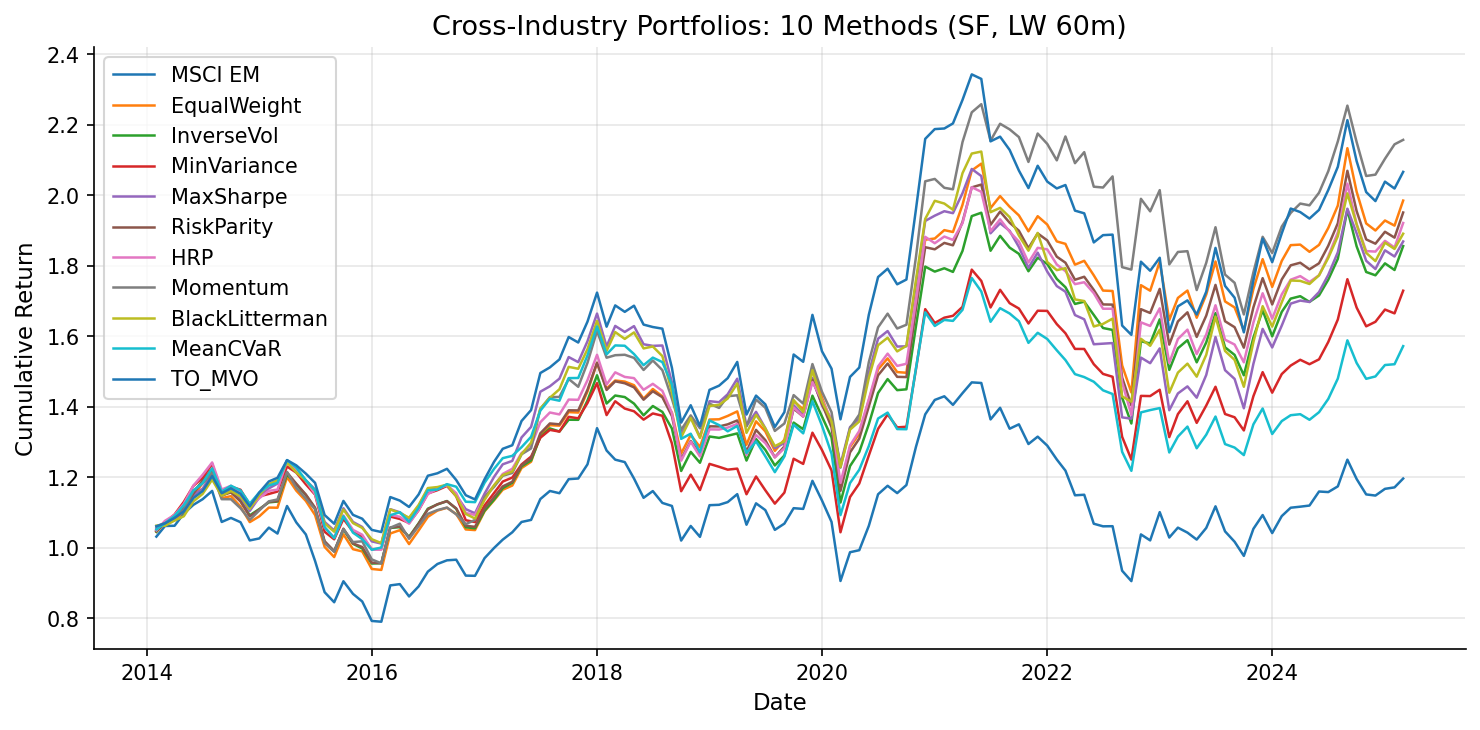

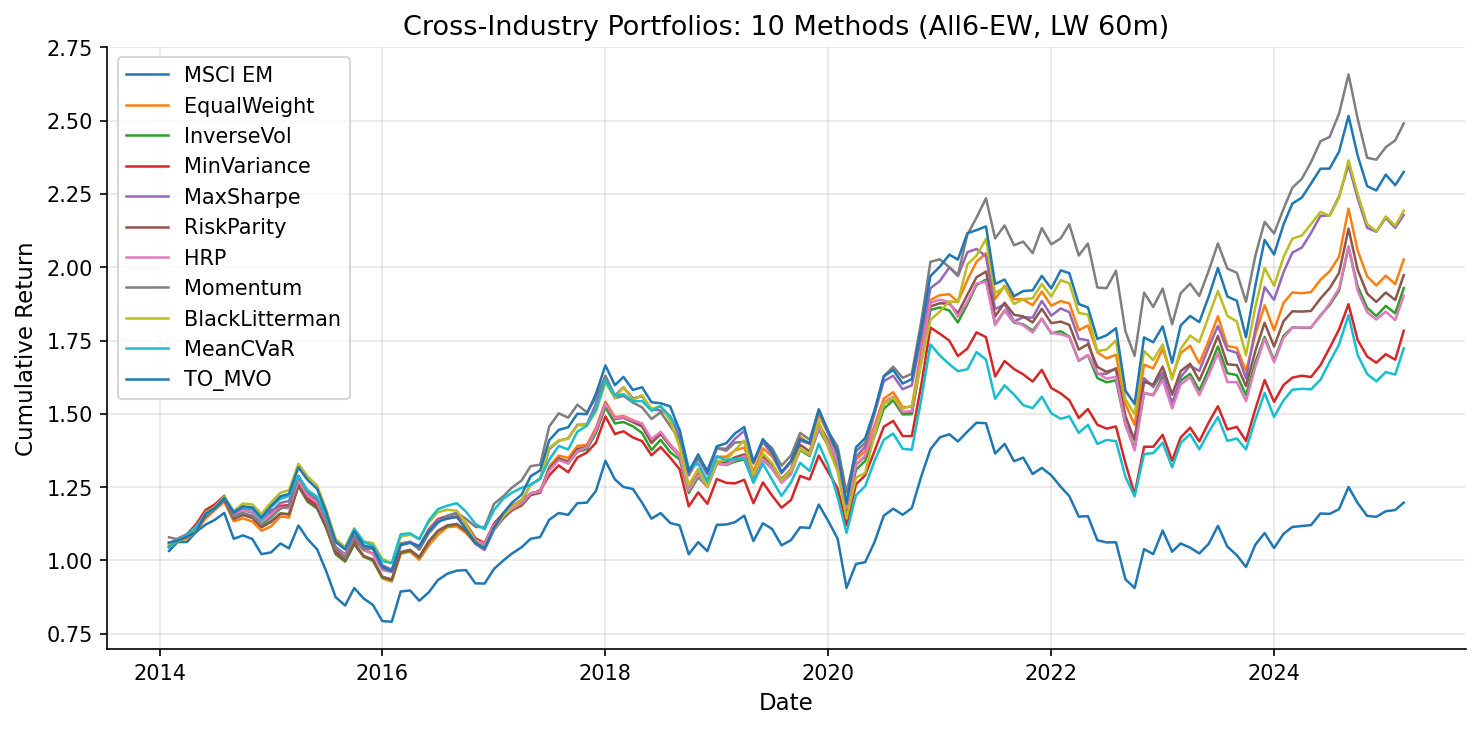

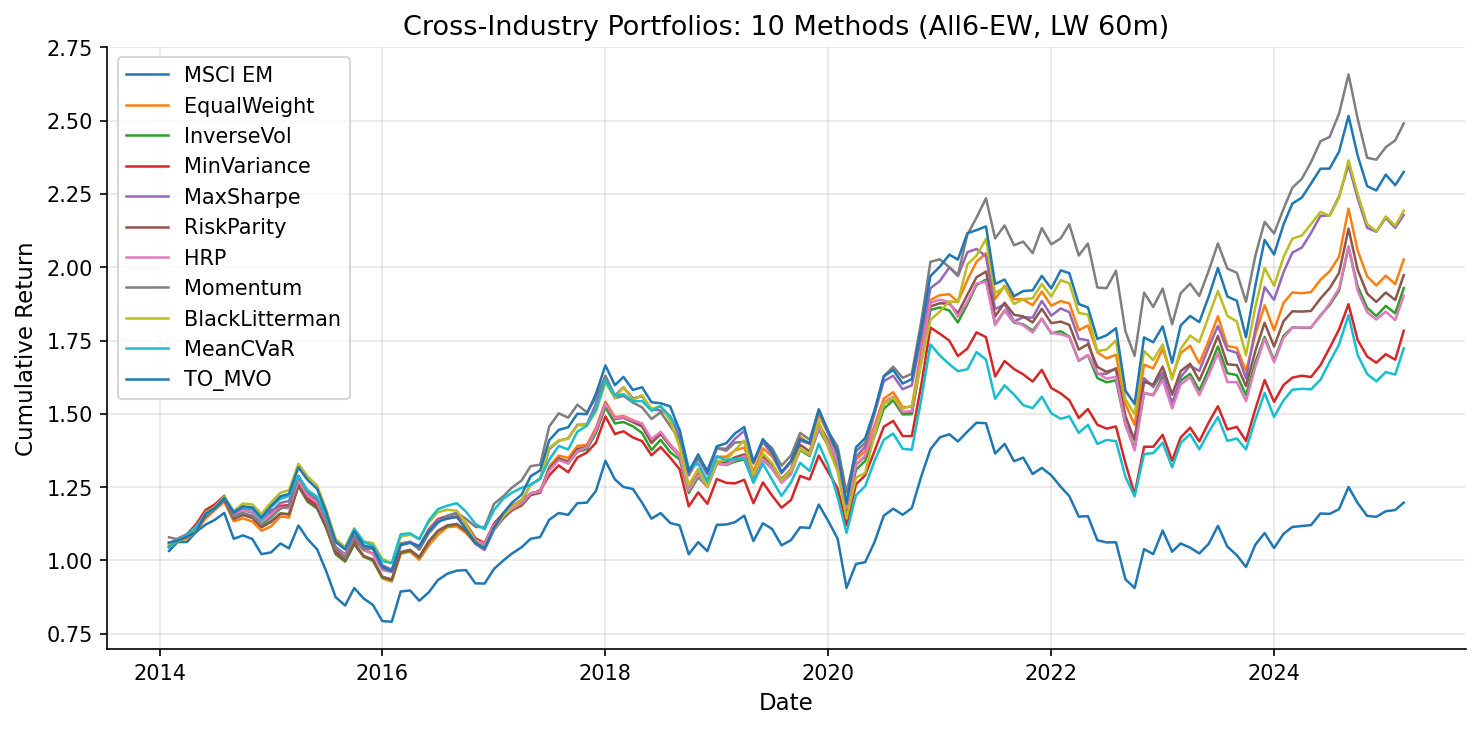

In [8]:
os.makedirs(f'{OUTPUT_DIR}/figures', exist_ok=True)

plot_cumulative_returns(
    sf_bench,
    title='Cross-Industry Portfolios: 10 Methods (SF, LW 60m)',
    save_path=f'{OUTPUT_DIR}/figures/exp4_cumulative_sf_lw60.pdf',
)
plot_cumulative_returns(
    {'MSCI EM': benchmark.loc[common], **a6_bench},
    title='Cross-Industry Portfolios: 10 Methods (All6-EW, LW 60m)',
    save_path=f'{OUTPUT_DIR}/figures/exp4_cumulative_a6_lw60.pdf',
)

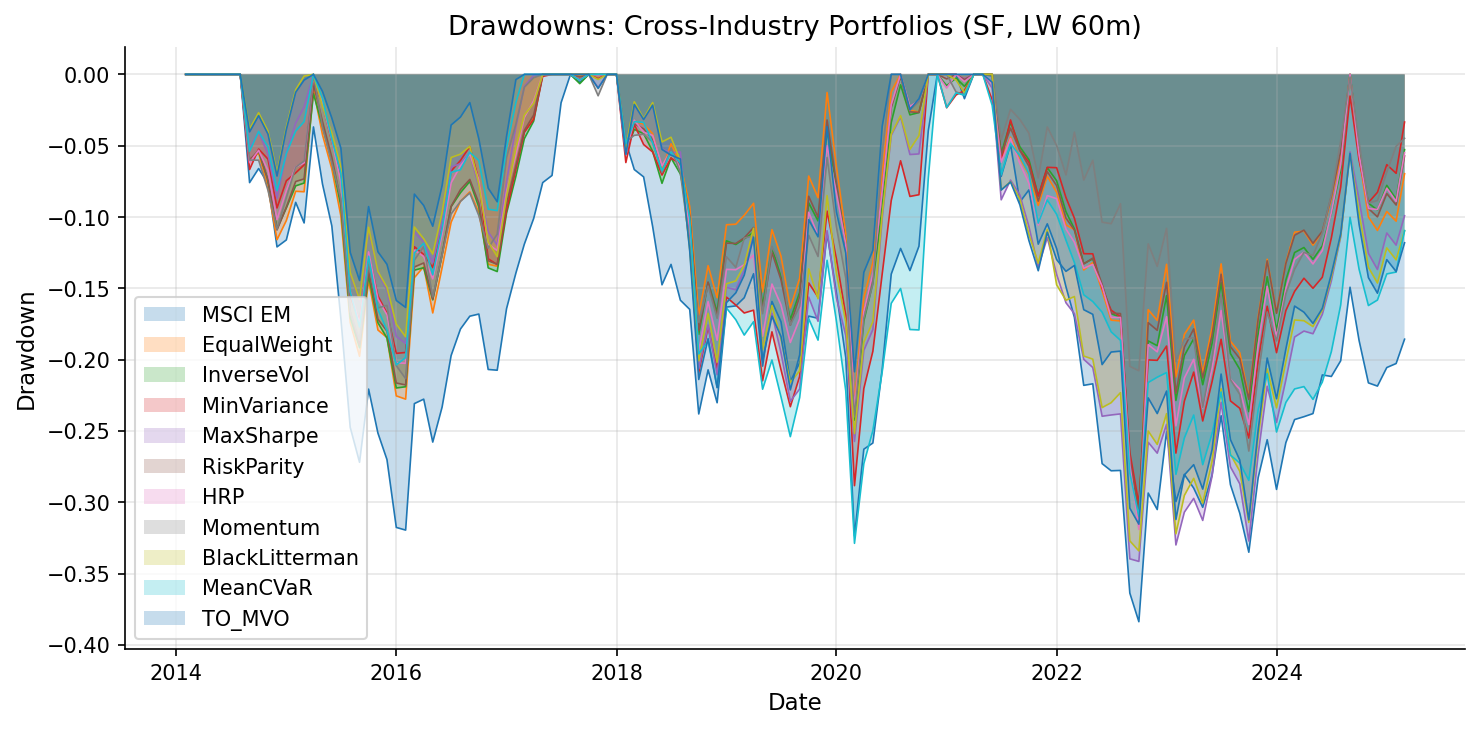

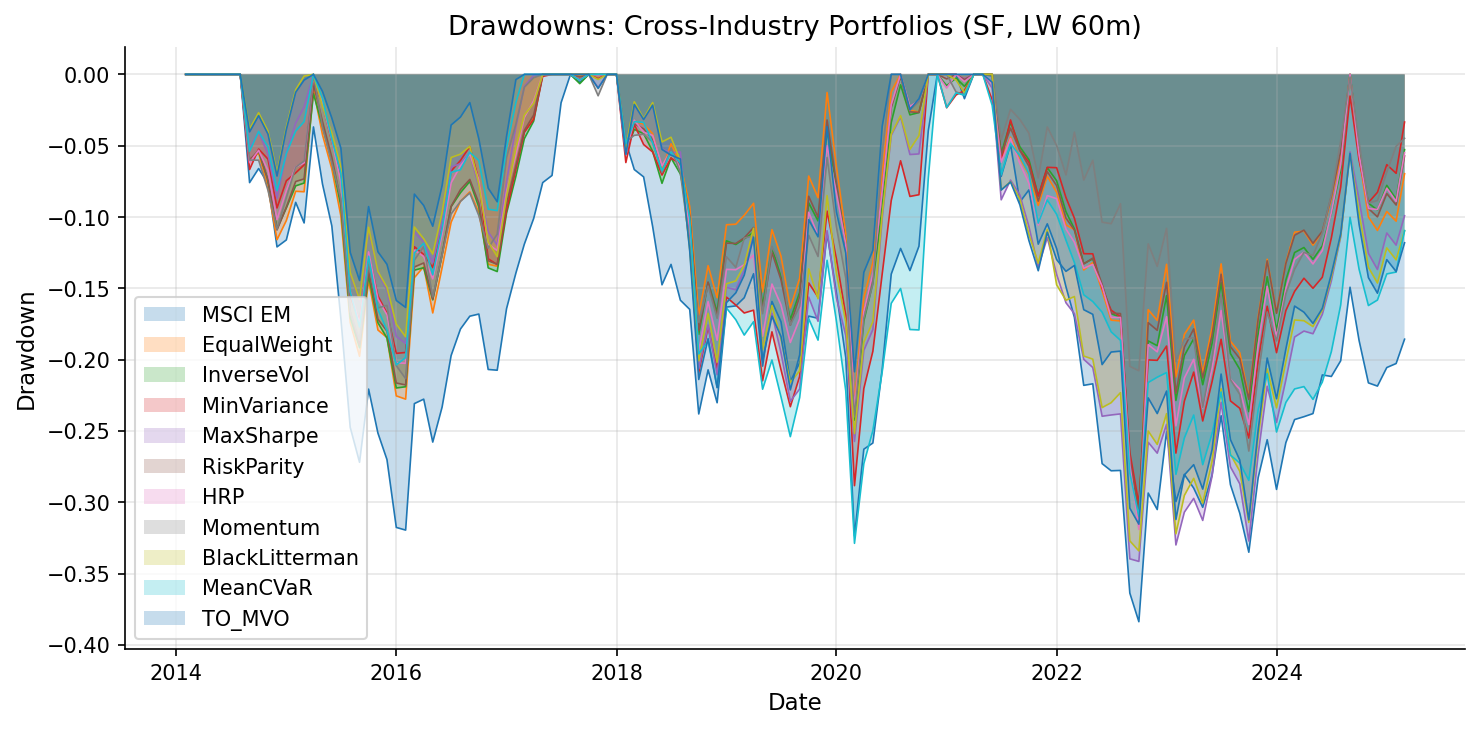

In [9]:
plot_drawdown(
    sf_bench,
    title='Drawdowns: Cross-Industry Portfolios (SF, LW 60m)',
    save_path=f'{OUTPUT_DIR}/figures/exp4_drawdown_sf_lw60.pdf',
)

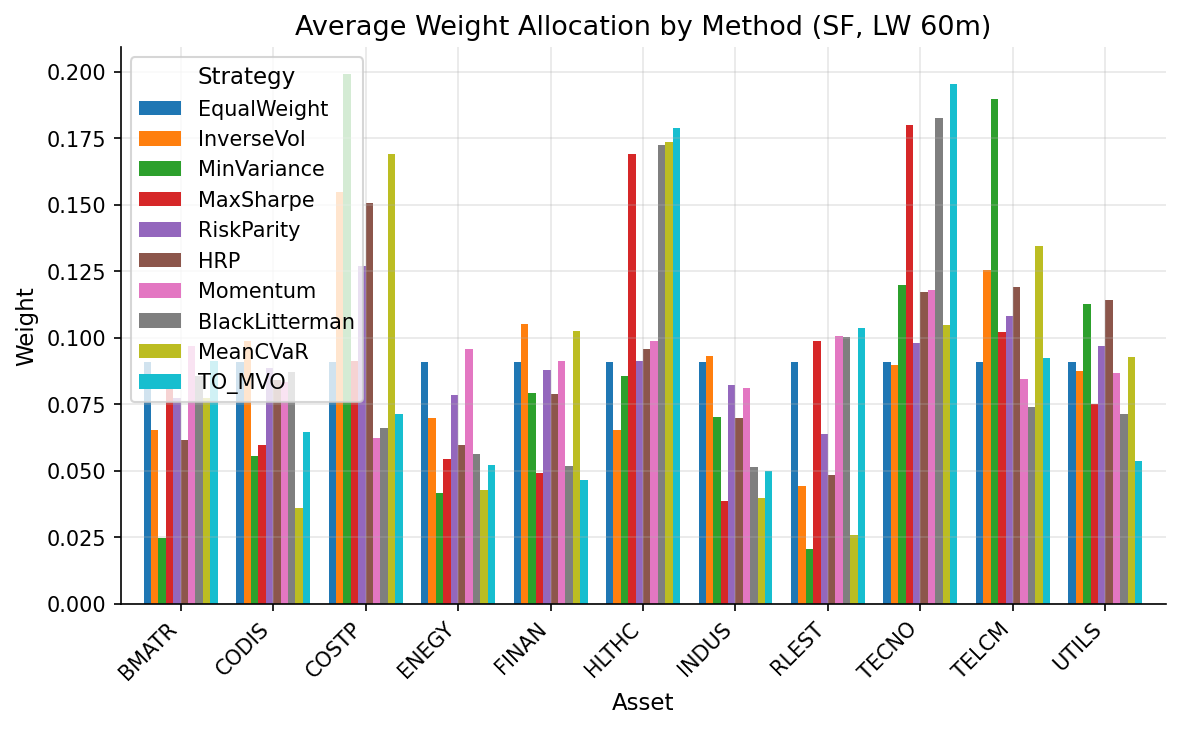

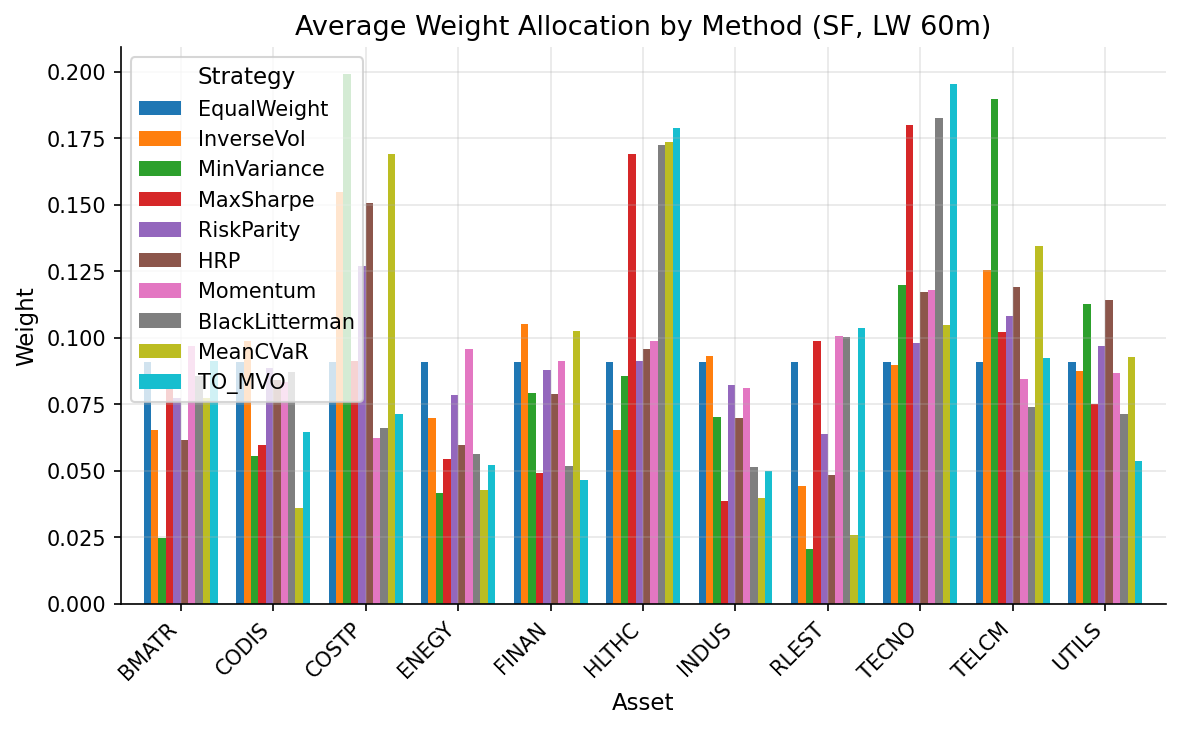

In [10]:
industries = list(sf_returns.columns)
avg_weights_sf = {}
for m in ALL_METHODS:
    avg_weights_sf[m] = weights_store[f'{m}_SF_LW_60m'].mean(axis=0)

plot_weight_bars(
    avg_weights_sf,
    labels=industries,
    title='Average Weight Allocation by Method (SF, LW 60m)',
    save_path=f'{OUTPUT_DIR}/figures/exp4_weights_sf_lw60.pdf',
)

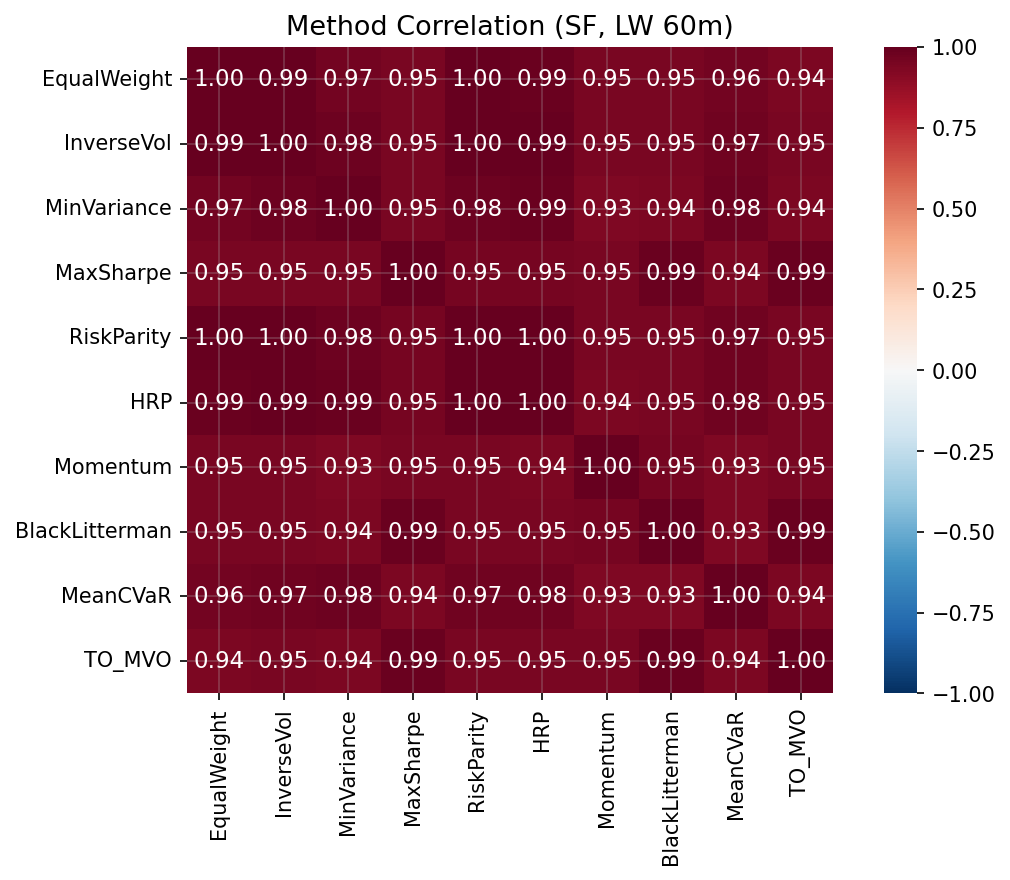

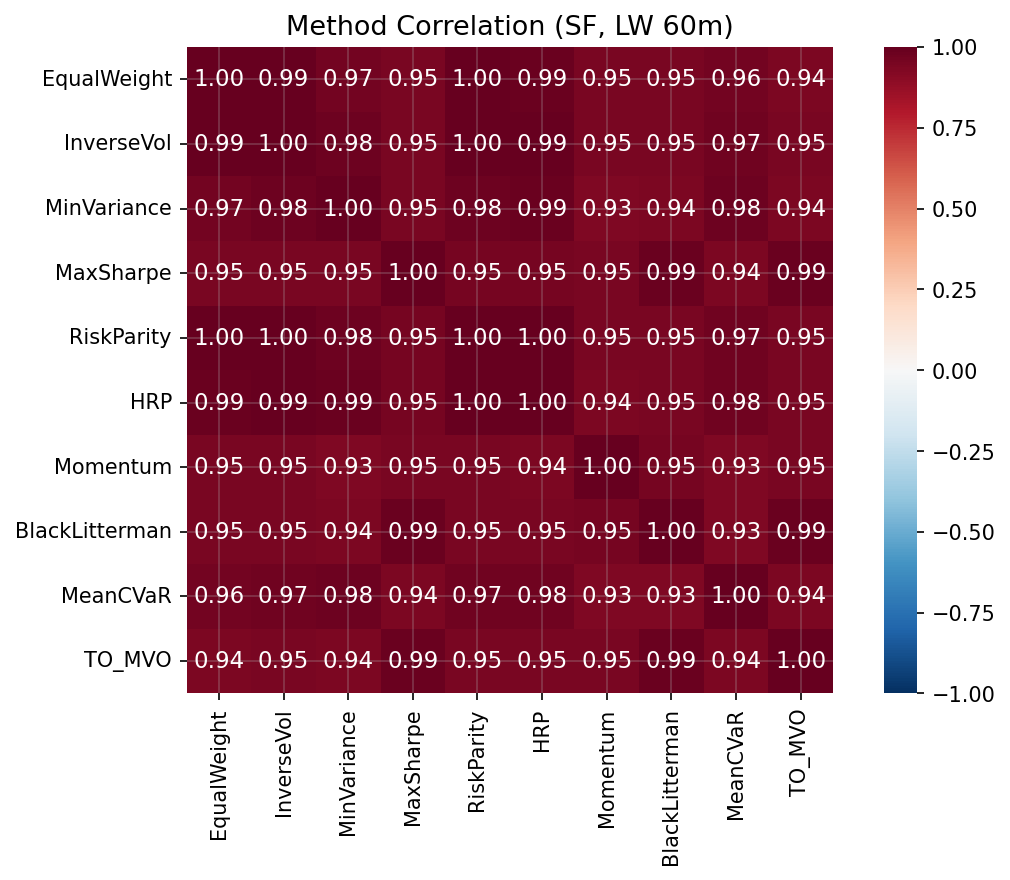

In [11]:
sf_lw60_df = pd.DataFrame(sf_lw60)

plot_correlation_heatmap(
    sf_lw60_df,
    title='Method Correlation (SF, LW 60m)',
    save_path=f'{OUTPUT_DIR}/figures/exp4_method_corr_sf_lw60.pdf',
)

In [12]:
sharpe_sf = perf_sf['Sharpe'].drop('MSCI EM', errors='ignore')
sharpe_a6 = perf_a6['Sharpe']
best_sf = sharpe_sf.idxmax()
best_a6 = sharpe_a6.idxmax()

print('=== Method Ranking by Sharpe (LW 60m) ===')
print(f'\nSingle-Factor input:')
print(sharpe_sf.sort_values(ascending=False).round(4).to_string())
print(f'  Best: {best_sf} ({sharpe_sf[best_sf]:.4f})')

print(f'\nAll6-EW input:')
print(sharpe_a6.sort_values(ascending=False).round(4).to_string())
print(f'  Best: {best_a6} ({sharpe_a6[best_a6]:.4f})')

=== Method Ranking by Sharpe (LW 60m) ===

Single-Factor input:
Strategy
Momentum          0.5181
TO_MVO            0.4809
EqualWeight       0.4501
RiskParity        0.4494
HRP               0.4449
BlackLitterman    0.4381
MaxSharpe         0.4315
InverseVol        0.4300
MinVariance       0.3933
MeanCVaR          0.3433
  Best: Momentum (0.5181)

All6-EW input:
Strategy
Momentum          0.5943
TO_MVO            0.5304
BlackLitterman    0.5068
MaxSharpe         0.5054
EqualWeight       0.4771
RiskParity        0.4652
InverseVol        0.4545
HRP               0.4439
MinVariance       0.4105
MeanCVaR          0.3925
  Best: Momentum (0.5943)


## 6. Window Sensitivity: 36m vs 60m (SF input, LW cov)

In [13]:
print('=== Window Sensitivity: 36m vs 60m (SF, LW) ===')
print(f'{"Method":15s}  {"36m Sharpe":>12s}  {"60m Sharpe":>12s}  {"Diff":>8s}')
print('-' * 55)

for m in ALL_METHODS:
    s36 = results[f'{m}_SF_LW_36m'].dropna()
    s60 = results[f'{m}_SF_LW_60m'].dropna()
    sr36 = s36.mean() * 12 / (s36.std() * np.sqrt(12)) if s36.std() > 0 else np.nan
    sr60 = s60.mean() * 12 / (s60.std() * np.sqrt(12)) if s60.std() > 0 else np.nan
    print(f'{m:15s}  {sr36:12.4f}  {sr60:12.4f}  {sr60 - sr36:+8.4f}')

=== Window Sensitivity: 36m vs 60m (SF, LW) ===
Method             36m Sharpe    60m Sharpe      Diff
-------------------------------------------------------
EqualWeight            0.4396        0.4501   +0.0104
InverseVol             0.4180        0.4300   +0.0120
MinVariance            0.3902        0.3933   +0.0031
MaxSharpe              0.4251        0.4315   +0.0064
RiskParity             0.4465        0.4494   +0.0028
HRP                    0.4699        0.4449   -0.0250
Momentum               0.5180        0.5181   +0.0001
BlackLitterman         0.4563        0.4381   -0.0182
MeanCVaR               0.4234        0.3433   -0.0801
TO_MVO                 0.4044        0.4809   +0.0764


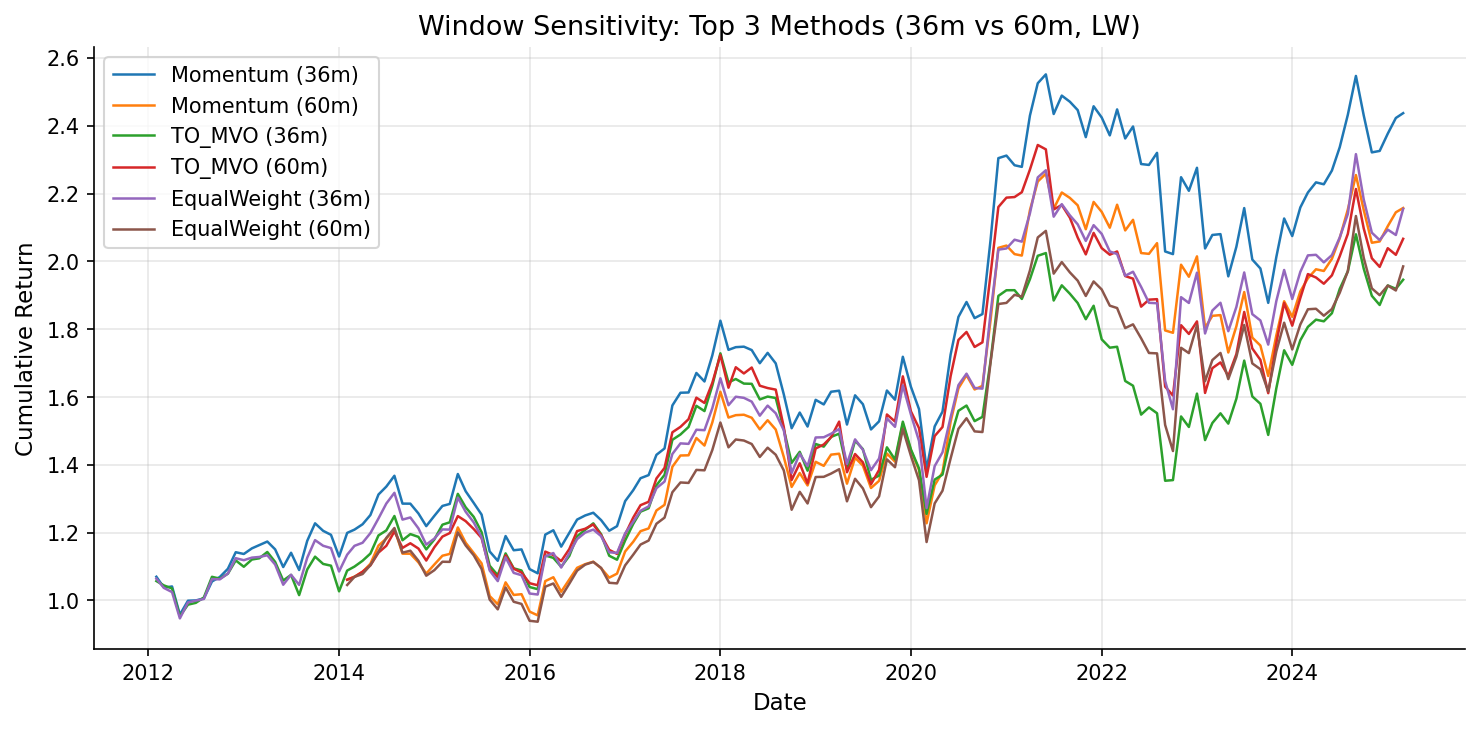

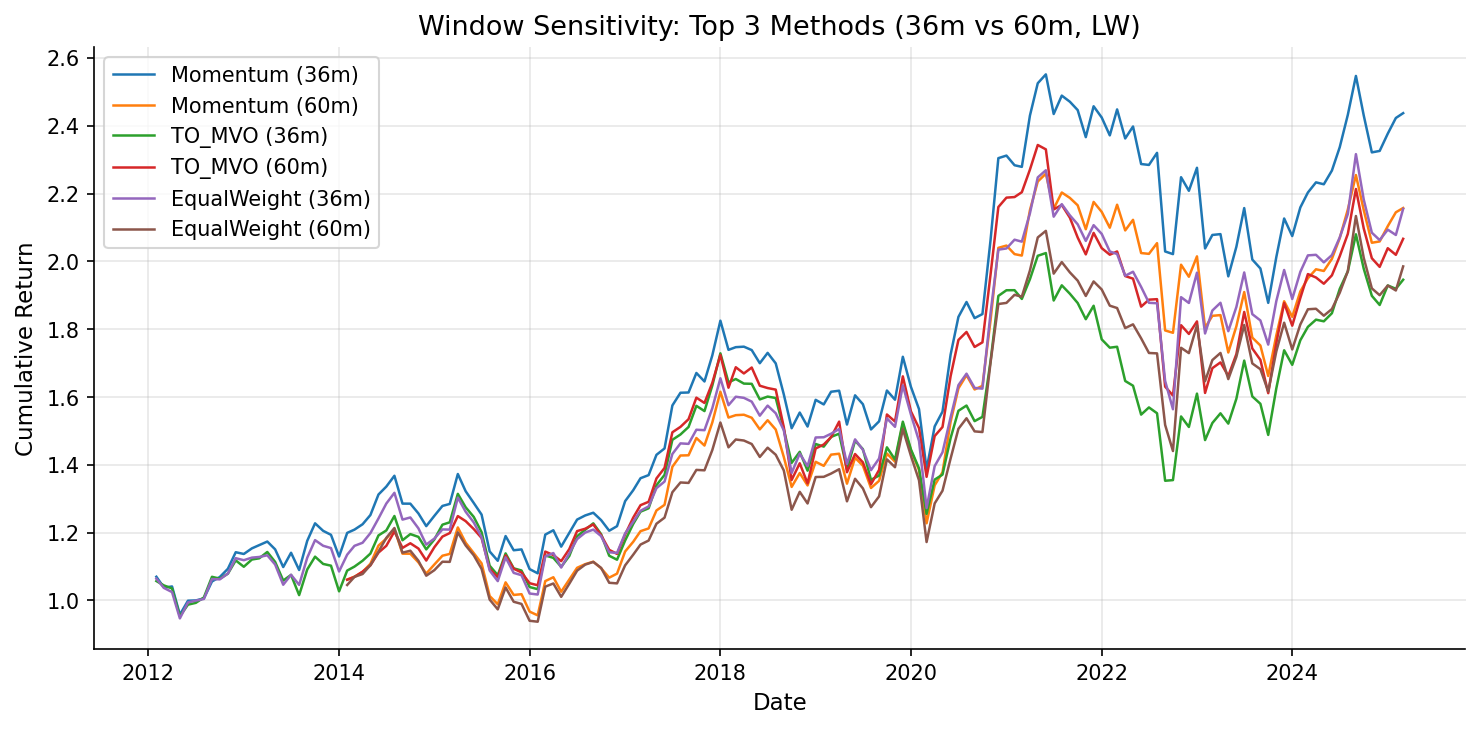

In [14]:
top3 = sharpe_sf.sort_values(ascending=False).head(3).index.tolist()

window_comp = {}
for m in top3:
    window_comp[f'{m} (36m)'] = results[f'{m}_SF_LW_36m']
    window_comp[f'{m} (60m)'] = results[f'{m}_SF_LW_60m']

plot_cumulative_returns(
    window_comp,
    title='Window Sensitivity: Top 3 Methods (36m vs 60m, LW)',
    save_path=f'{OUTPUT_DIR}/figures/exp4_window_sensitivity.pdf',
)

## 7. Covariance Sensitivity: LW vs Sample vs EWMA (SF, 60m)

In [15]:
cov_names = ['LW', 'Sample', 'EWMA']

print('=== Covariance Sensitivity (SF, 60m window) ===')
header = f'{"Method":15s}' + ''.join(f'  {c:>12s}' for c in cov_names)
print(header)
print('-' * len(header))

for m in ALL_METHODS:
    vals = []
    for cn in cov_names:
        s = results[f'{m}_SF_{cn}_60m'].dropna()
        sr = s.mean() * 12 / (s.std() * np.sqrt(12)) if s.std() > 0 else np.nan
        vals.append(sr)
    row = f'{m:15s}' + ''.join(f'  {v:12.4f}' for v in vals)
    print(row)

=== Covariance Sensitivity (SF, 60m window) ===
Method                     LW        Sample          EWMA
---------------------------------------------------------
EqualWeight            0.4501        0.4501        0.4501
InverseVol             0.4300        0.4235        0.4157
MinVariance            0.3933        0.3982        0.3804
MaxSharpe              0.4315        0.4257        0.4037
RiskParity             0.4494        0.4498        0.4511
HRP                    0.4449        0.4442        0.4414
Momentum               0.5181        0.5181        0.5181
BlackLitterman         0.4381        0.4466        0.4091
MeanCVaR               0.3433        0.3433        0.3433
TO_MVO                 0.4809        0.4954        0.4355


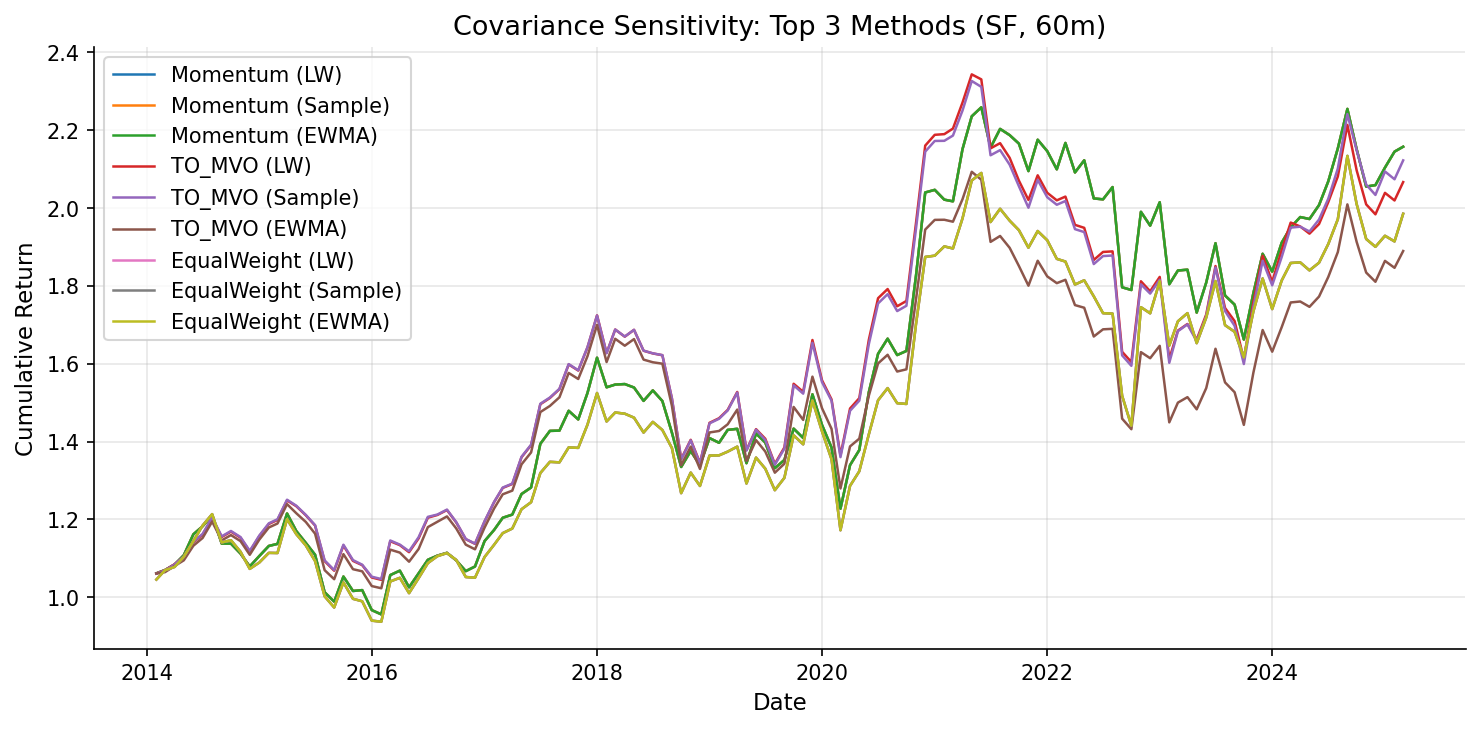

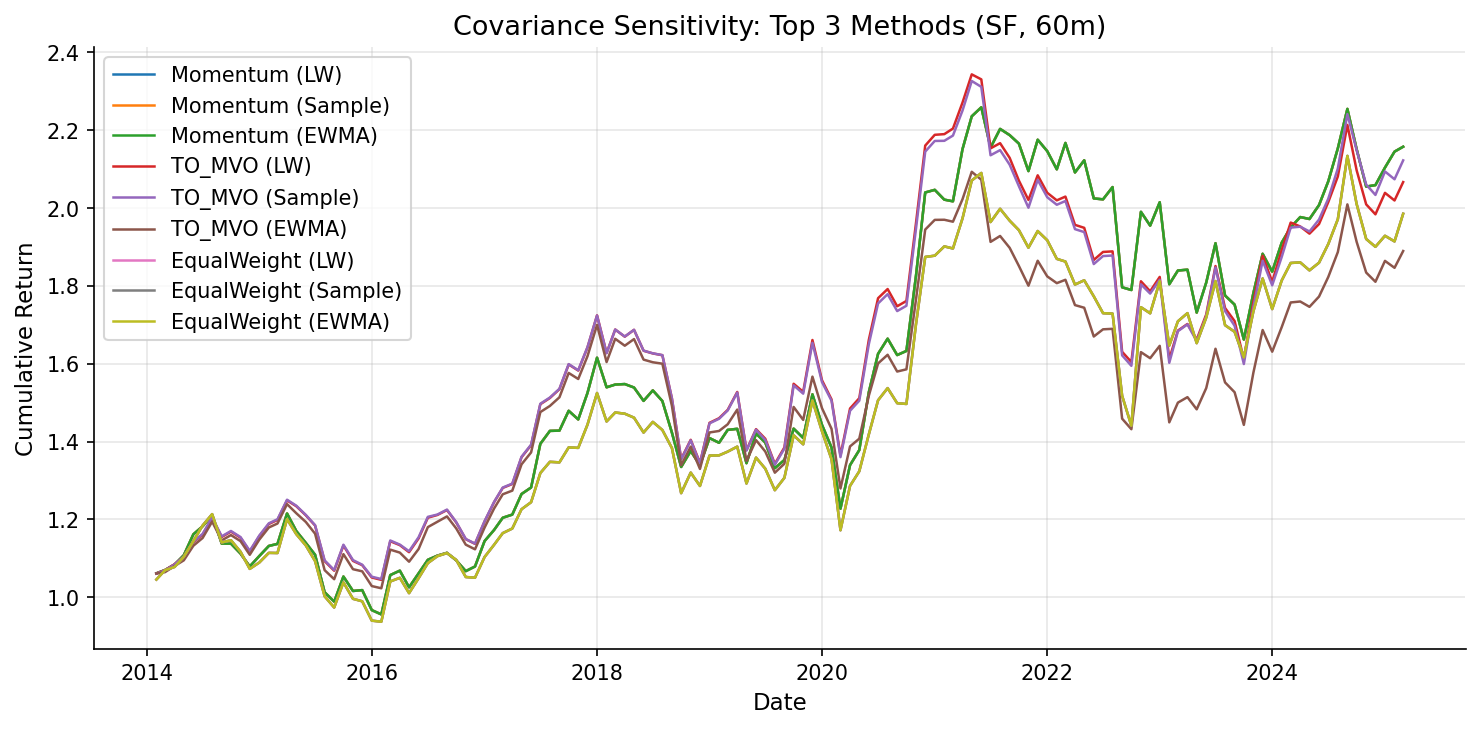

In [16]:
cov_comp = {}
for m in top3:
    for cn in cov_names:
        cov_comp[f'{m} ({cn})'] = results[f'{m}_SF_{cn}_60m']

plot_cumulative_returns(
    cov_comp,
    title='Covariance Sensitivity: Top 3 Methods (SF, 60m)',
    save_path=f'{OUTPUT_DIR}/figures/exp4_cov_sensitivity.pdf',
)

## 8. Portfolio-Level Turnover Analysis

In [17]:
print('=== Monthly Turnover by Method (LW 60m) ===')
print(f'{"Method":15s}  {"SF Turnover":>12s}  {"All6EW TO":>12s}')
print('-' * 45)

for m in ALL_METHODS:
    w_sf = weights_store[f'{m}_SF_LW_60m']
    w_a6 = weights_store[f'{m}_All6EW_LW_60m']
    to_sf = np.mean([np.sum(np.abs(w_sf[i] - w_sf[i-1])) / 2
                     for i in range(1, len(w_sf))])
    to_a6 = np.mean([np.sum(np.abs(w_a6[i] - w_a6[i-1])) / 2
                     for i in range(1, len(w_a6))])
    print(f'{m:15s}  {to_sf:12.4f}  {to_a6:12.4f}')

=== Monthly Turnover by Method (LW 60m) ===
Method            SF Turnover     All6EW TO
---------------------------------------------
EqualWeight            0.0000        0.0000
InverseVol             0.0096        0.0097
MinVariance            0.0236        0.0262
MaxSharpe              0.0577        0.0557
RiskParity             0.0073        0.0071
HRP                    0.0455        0.0424
Momentum               0.1060        0.0990
BlackLitterman         0.0639        0.0590
MeanCVaR               0.0218        0.0199
TO_MVO                 0.0203        0.0170


## 9. Save Results

In [18]:
os.makedirs(f'{OUTPUT_DIR}/csv', exist_ok=True)

all_returns_df = pd.DataFrame(results)
all_returns_df.to_csv(f'{OUTPUT_DIR}/csv/exp4_all_portfolio_returns.csv')

sf_lw60_df.to_csv(f'{OUTPUT_DIR}/csv/exp4_sf_lw60_returns.csv')
a6_lw60_df = pd.DataFrame(a6_lw60)
a6_lw60_df.to_csv(f'{OUTPUT_DIR}/csv/exp4_a6_lw60_returns.csv')

perf_sf.to_csv(f'{OUTPUT_DIR}/csv/exp4_performance_sf_lw60.csv')
perf_a6.to_csv(f'{OUTPUT_DIR}/csv/exp4_performance_a6_lw60.csv')

avg_w_df = pd.DataFrame(avg_weights_sf, index=industries)
avg_w_df.to_csv(f'{OUTPUT_DIR}/csv/exp4_average_weights_sf_lw60.csv')

full_perf = performance_table(results)
full_perf.to_csv(f'{OUTPUT_DIR}/csv/exp4_full_performance_grid.csv')

# Combined table for downstream use
combined = pd.DataFrame({
    'SF_Sharpe': sharpe_sf,
    'All6EW_Sharpe': sharpe_a6,
})
combined.to_csv(f'{OUTPUT_DIR}/csv/exp4_combined_sharpe.csv')

print('Experiment 4 results saved.')
for fname in ['exp4_all_portfolio_returns.csv', 'exp4_sf_lw60_returns.csv',
              'exp4_comp_lw60_returns.csv', 'exp4_combined_sharpe.csv']:
    print(f'  {fname}')

Experiment 4 results saved.
  exp4_all_portfolio_returns.csv
  exp4_sf_lw60_returns.csv
  exp4_comp_lw60_returns.csv
  exp4_combined_sharpe.csv


## 10. Summary

Key findings from Experiment 4:

1. 10 cross-industry allocation methods compared on both Single-Factor
   and IC-Composite industry portfolio return series.
2. Ledoit-Wolf covariance with 60-month rolling window used as primary
   estimator; 36m window and alternative estimators tested for sensitivity.
3. Combined performance table shows Sharpe, MaxDD, and turnover for all
   20 variants (10 methods x 2 inputs).
4. TO_MVO uses previous-period weights to penalise turnover; Momentum
   weights by trailing returns; Black-Litterman blends prior with views;
   Mean-CVaR targets tail-risk minimisation.